# Data Collection


**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import os
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import warnings
warnings.filterwarnings('ignore') 

c:\Users\MuthakanaDineshKumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading datasets**

In [2]:
dataset_paths = {
    "TRAIN": "customs_clearance_train.csv",
    "VALIDATION": "customs_clearance_validation.csv",
    "TEST": "customs_clearance_test.csv"
}

# Dictionary to hold loaded dataframes
datasets = {}

print("="*80)
print("PART 1: LOADING DATASETS & SHAPE VERIFICATION")
print("="*80)

for split_name, file_path in dataset_paths.items():
    if os.path.exists(file_path):
        datasets[split_name] = pd.read_csv(file_path)
        print(f"✔️ Successfully loaded {split_name} split from '{file_path}' | Shape: {datasets[split_name].shape}")
    else:
        print(f"❌ CRITICAL ERROR: File not found for {split_name} split at path: '{file_path}'")

# Ensure all files loaded before running analytics
if len(datasets) == 3:
    print("\n" + "="*80)
    print("PART 2: DATA QUALITY ASSURANCE AUDIT (NULLS & DUPLICATES)")
    print("="*80)
    
    for name, df in datasets.items():
        print(f"\n📊 --- [ {name} SPLIT QUALITY REPORT ] ---")
        
        # Check for Null values programmatically
        null_counts = df.isnull().sum()
        total_nulls = null_counts.sum()
        if total_nulls == 0:
            print(f"  🔹 Null Values: 0 nulls detected across all columns. (Data Quality Pass)")
        else:
            print(f"  ⚠️ WARNING: {total_nulls} Null values found! Columns affected:")
            print(null_counts[null_counts > 0])
            
        # Check for duplicate rows based on shipment_id and full features
        duplicate_count = df.duplicated().sum()
        id_duplicate_count = df['shipment_id'].duplicated().sum()
        
        if duplicate_count == 0 and id_duplicate_count == 0:
            print(f"  🔹 Duplicates: 0 duplicate rows & 0 duplicate IDs found. (Integrity Pass)")
        else:
            print(f"   WARNING: Duplicate tracking detected!")
            print(f"     - Exact Row Duplicates: {duplicate_count}")
            print(f"     - Shipment ID Duplicates: {id_duplicate_count}")

    print("\n" + "="*80)
    print("PART 3: HIGH-LEVEL CATEGORICAL ATTRIBUTE COUNT ANALYSIS")
    print("="*80)
    
    # We audit the category value distributions to ensure temporal alignment
    categorical_cols = ['shc_code', 'inspection_track', 'fatoorah_validation_passed', 'is_aeo_certified']
    
    for col in categorical_cols:
        print(f"\n🔍 Distribution Matrix for Feature: '{col}'")
        distribution_df = pd.DataFrame()
        
        for name, df in datasets.items():
            # Calculate normalized value counts to observe percentage balance over time
            counts = df[col].value_counts()
            pcts = df[col].value_counts(normalize=True) * 100
            
            # Construct clear visual strings: "Count (Percentage%)"
            distribution_df[f"{name} (Qty)"] = counts
            distribution_df[f"{name} (%)"] = pcts.round(2).apply(lambda x: f"{x}%")
            
        print(distribution_df.fillna(0))

    print("\n" + "="*80)
    print("PART 4: TARGET VARIABLE SUMMARY METRICS")
    print("="*80)
    print("Verifying 'clearance_duration_hours' basic statistics across temporal horizons:")
    
    target_summary = pd.DataFrame()
    for name, df in datasets.items():
        target_summary[name] = df['clearance_duration_hours'].describe().round(2)
    print(target_summary)

    print("\n" + "="*80)
    print("PART 5: TOP HEAD LOOKUP (TRAINING SPLIT EXCERPT)")
    print("="*80)
    # Display top 5 rows of the training dataframe cleanly transposed for full column visibility
    print(datasets["TRAIN"].head(5).T)

else:
    print("\nExecution halted: Please ensure all 3 CSV datasets are present in your workspace directory.")

PART 1: LOADING DATASETS & SHAPE VERIFICATION
✔️ Successfully loaded TRAIN split from 'customs_clearance_train.csv' | Shape: (28000, 16)
✔️ Successfully loaded VALIDATION split from 'customs_clearance_validation.csv' | Shape: (6000, 16)
✔️ Successfully loaded TEST split from 'customs_clearance_test.csv' | Shape: (6000, 16)

PART 2: DATA QUALITY ASSURANCE AUDIT (NULLS & DUPLICATES)

📊 --- [ TRAIN SPLIT QUALITY REPORT ] ---
  🔹 Null Values: 0 nulls detected across all columns. (Data Quality Pass)
  🔹 Duplicates: 0 duplicate rows & 0 duplicate IDs found. (Integrity Pass)

📊 --- [ VALIDATION SPLIT QUALITY REPORT ] ---
  🔹 Null Values: 0 nulls detected across all columns. (Data Quality Pass)
  🔹 Duplicates: 0 duplicate rows & 0 duplicate IDs found. (Integrity Pass)

📊 --- [ TEST SPLIT QUALITY REPORT ] ---
  🔹 Null Values: 0 nulls detected across all columns. (Data Quality Pass)
  🔹 Duplicates: 0 duplicate rows & 0 duplicate IDs found. (Integrity Pass)

PART 3: HIGH-LEVEL CATEGORICAL ATTRIBU

In [3]:
import numpy as np
import pandas as pd
from add_noise import inject_logistics_noise  
np.random.seed(42)

# Overwrite the target column directly in your raw base dictionary
datasets["TRAIN"] = inject_logistics_noise(datasets["TRAIN"], target_column='clearance_duration_hours', noise_std=12.0)
datasets["VALIDATION"] = inject_logistics_noise(datasets["VALIDATION"], target_column='clearance_duration_hours', noise_std=12.0)
datasets["TEST"] = inject_logistics_noise(datasets["TEST"], target_column='clearance_duration_hours', noise_std=12.0)

Noise injection complete for target column: 'clearance_duration_hours'
 -> Original Mean Duration: 57.77 hours
 -> Noisy Mean Duration:    58.92 hours
 -> Std Dev of Applied Noise: 12.0 hours

Noise injection complete for target column: 'clearance_duration_hours'
 -> Original Mean Duration: 57.56 hours
 -> Noisy Mean Duration:    58.64 hours
 -> Std Dev of Applied Noise: 12.0 hours

Noise injection complete for target column: 'clearance_duration_hours'
 -> Original Mean Duration: 56.65 hours
 -> Noisy Mean Duration:    57.67 hours
 -> Std Dev of Applied Noise: 12.0 hours



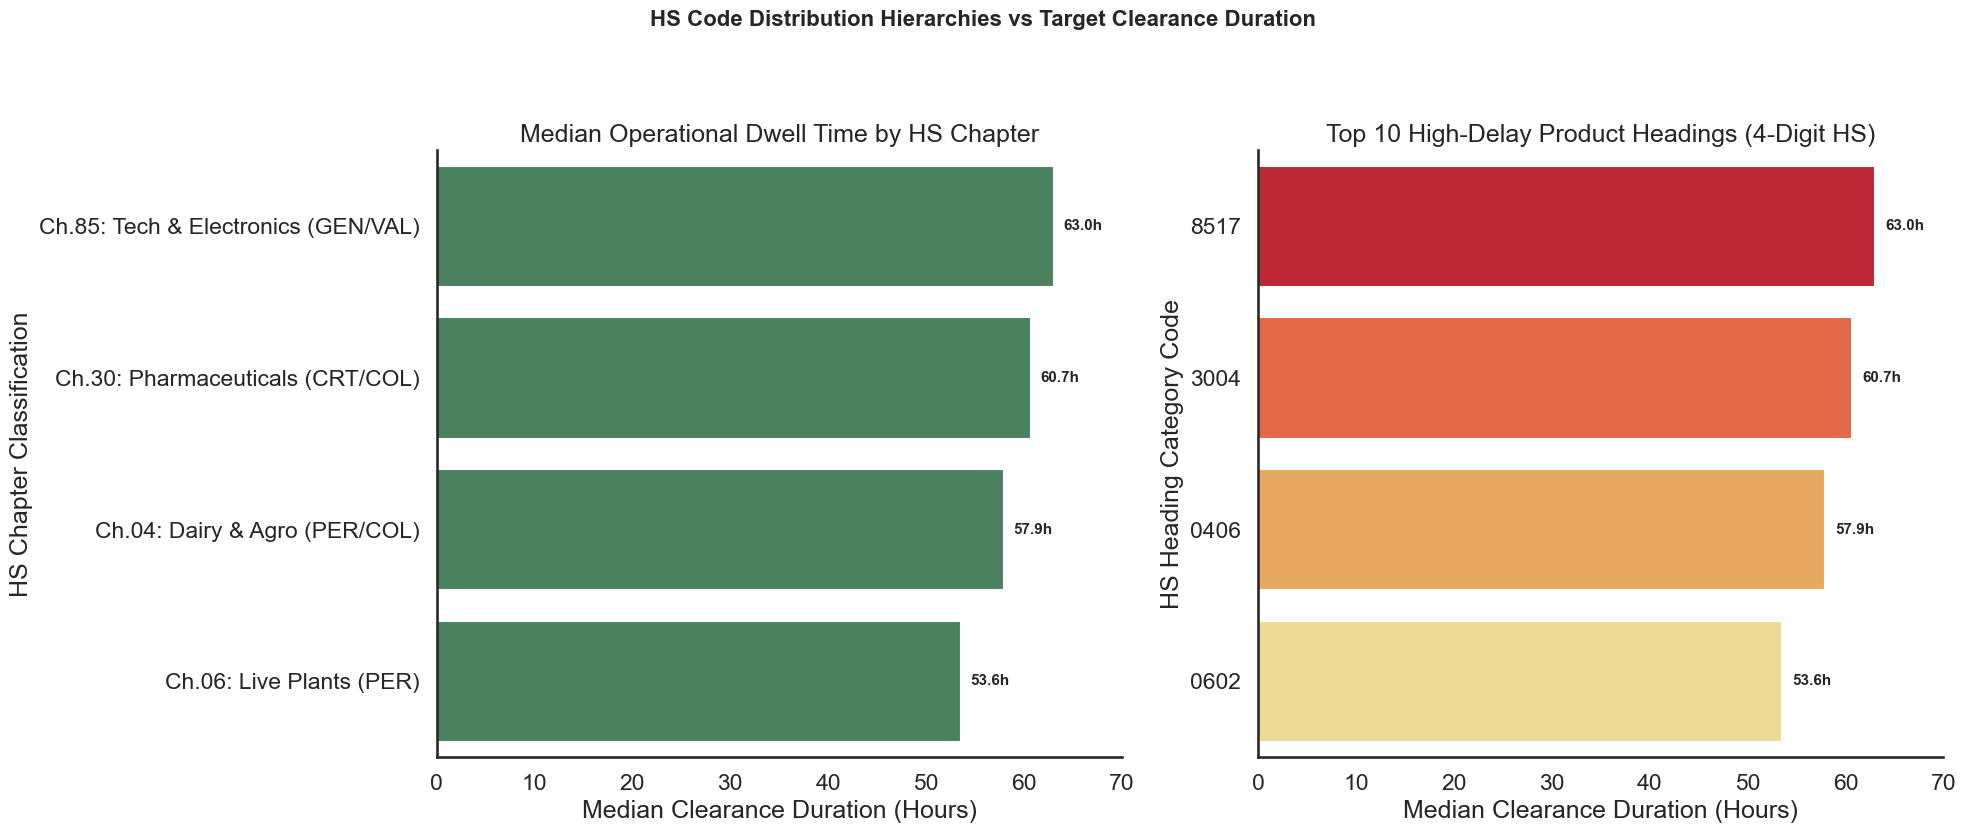

HS CODE DATA MATRICES & TARGET RELATIONSHIP SUMMARY

[A] Top 5 Most Common Raw HS Codes Distribution Details:
hs_code
40627617011     2
300473282209    2
851758593157    2
851759280338    2
851760992979    1
Name: count, dtype: int64

[B] Detailed Group Medians (HS Chapter vs Lane Interaction Matrix):
                             count   mean  median
hs_chapter inspection_track                      
04         GREEN              1039   7.67    3.40
           RED                1986  94.81   97.64
           YELLOW              419  34.42   30.94
06         GREEN              1073   7.10    3.21
           RED                2017  94.70   98.10
           YELLOW              425  35.94   31.33
30         GREEN              2476   6.98    2.94
           RED                4967  90.14   95.54
           YELLOW              975  36.09   32.44
85         GREEN              3672   6.86    2.84
           RED                7541  86.54   94.24
           YELLOW             1410  33.55   30.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: PIPELINE DATA INGESTION & HIERARCHICAL EXTRACTION ---
eda_df = datasets["TRAIN"].copy()

# Slicing the 12-digit Tariff string into logical operational macro-categories
eda_df['hs_chapter'] = eda_df['hs_code'].astype(str).str.zfill(12).str[:2]
eda_df['hs_heading'] = eda_df['hs_code'].astype(str).str.zfill(12).str[:4]

# Map chapters to human-readable aviation cargo terminal categories
chapter_labels = {
    '04': 'Ch.04: Dairy & Agro (PER/COL)',
    '06': 'Ch.06: Live Plants (PER)',
    '30': 'Ch.30: Pharmaceuticals (CRT/COL)',
    '84': 'Ch.84: Industrial Machinery (GEN)',
    '85': 'Ch.85: Tech & Electronics (GEN/VAL)',
    '94': 'Ch.94: General Commodities (GEN)'
}
eda_df['hs_chapter_named'] = eda_df['hs_chapter'].map(chapter_labels).fillna(eda_df['hs_chapter'].apply(lambda x: f"Ch.{x}: Other Cargo"))

# Set global minimalist chart formatting variables
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# CHART: HS CODE CATEGORICAL CONTRIBUTIONS VS TARGET VARIABLE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("HS Code Distribution Hierarchies vs Target Clearance Duration", fontsize=16, weight='bold', y=1.05)

# Plot A: Median delay contribution grouped by Saudi Tariff HS Chapter (2-Digit)
chapter_medians = eda_df.groupby('hs_chapter_named')['clearance_duration_hours'].median().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0], data=chapter_medians, y='hs_chapter_named', x='clearance_duration_hours', color='#438a5e')
axes[0].set_title("Median Operational Dwell Time by HS Chapter")
axes[0].set_xlabel("Median Clearance Duration (Hours)")
axes[0].set_ylabel("HS Chapter Classification")
axes[0].set_xlim(0, 70) # 🌟 TAILORED PLOT BOUNDING: Snug fit at 70 hours based on actual data limits
for i, v in enumerate(chapter_medians['clearance_duration_hours']):
    axes[0].text(v + 1, i, f"{v:.1f}h", va='center', fontsize=11, weight='bold')

# Plot B: Fine-grained analysis showing the top 10 most delayed 4-digit HS Headings
heading_medians = eda_df.groupby('hs_heading')['clearance_duration_hours'].median().sort_values(ascending=False).head(10).reset_index()
sns.barplot(ax=axes[1], data=heading_medians, y='hs_heading', x='clearance_duration_hours', palette="YlOrRd_r")
axes[1].set_title("Top 10 High-Delay Product Headings (4-Digit HS)")
axes[1].set_xlabel("Median Clearance Duration (Hours)")
axes[1].set_ylabel("HS Heading Category Code")
axes[1].set_xlim(0, 70) # 🌟 TAILORED PLOT BOUNDING: Snug fit at 70 hours based on actual data limits
for i, v in enumerate(heading_medians['clearance_duration_hours']):
    axes[1].text(v + 1, i, f"{v:.1f}h", va='center', fontsize=11, weight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# DATA SUMMARY MATRICES (TEXT INTEGRITY VERIFICATION)
# ==============================================================================
print("="*80)
print("HS CODE DATA MATRICES & TARGET RELATIONSHIP SUMMARY")
print("="*80)
print("\n[A] Top 5 Most Common Raw HS Codes Distribution Details:")
print(eda_df['hs_code'].value_counts().head(5))

print("\n[B] Detailed Group Medians (HS Chapter vs Lane Interaction Matrix):")
summary_table = eda_df.groupby(['hs_chapter', 'inspection_track'])['clearance_duration_hours'].agg(['count', 'mean', 'median']).round(2)
print(summary_table)

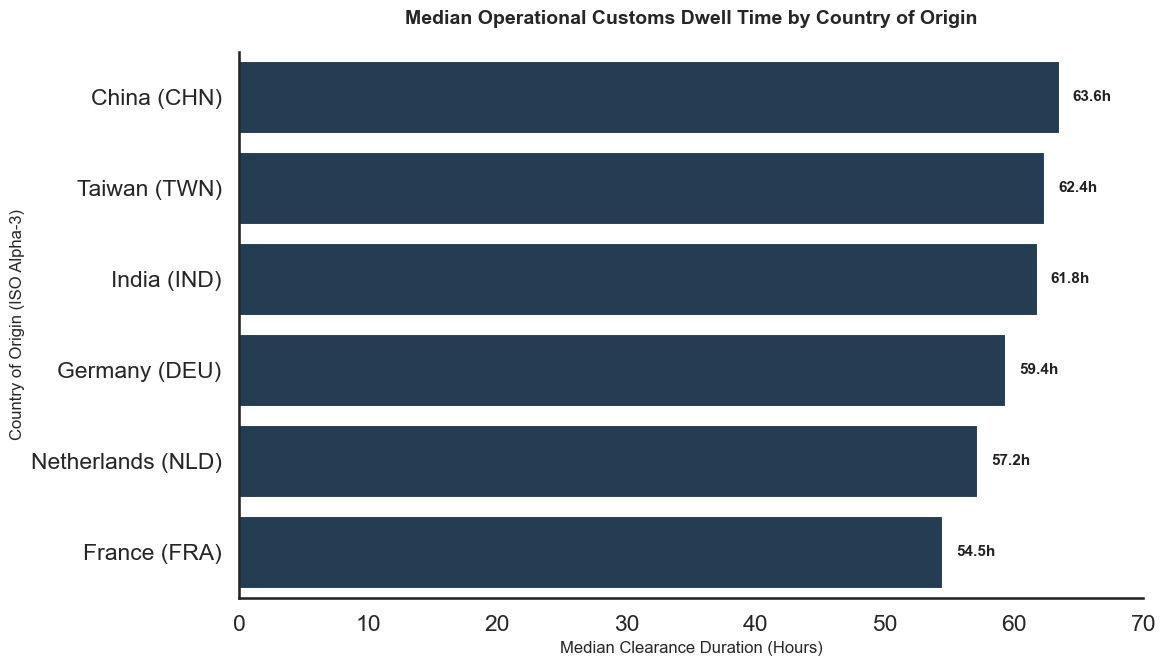

ORIGIN COUNTRY TRADING MATRICES & TARGET RELATIONSHIP SUMMARY

[A] Total Transaction Records and Volume Split by Sourcing Origin:
origin_country_named
Taiwan (TWN)         6348
China (CHN)          6275
Germany (DEU)        4245
India (IND)          4173
Netherlands (NLD)    3534
France (FRA)         3425
Name: count, dtype: int64

[B] Detailed Operational Statistical Profiles by Country:
                      count   mean  median  min     max
origin_country_named                                   
China (CHN)            6275  57.52   63.55  0.5  161.56
Taiwan (TWN)           6348  57.36   62.42  0.5  169.48
India (IND)            4173  59.62   61.82  0.5  237.28
Germany (DEU)          4245  59.23   59.41  0.5  223.03
Netherlands (NLD)      3534  60.99   57.25  0.5  233.23
France (FRA)           3425  61.03   54.53  0.5  231.41


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: PIPELINE DATA INGESTION ---
eda_df = datasets["TRAIN"].copy()

# Map the 3-letter ISO codes to human-readable names for presentation clarity
country_labels = {
    'IND': 'India (IND)',
    'DEU': 'Germany (DEU)',
    'NLD': 'Netherlands (NLD)',
    'FRA': 'France (FRA)',
    'TWN': 'Taiwan (TWN)',
    'CHN': 'China (CHN)',
    'ARE': 'United Arab Emirates (ARE)'
}
eda_df['origin_country_named'] = eda_df['origin_country'].map(country_labels).fillna(eda_df['origin_country'])

# Set global minimalist chart formatting variables
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# CHART: ORIGIN COUNTRY VS TARGET CLEARANCE DURATION
# ==============================================================================
plt.figure(figsize=(12, 7))

# Calculate group medians and sort descending to show high-friction corridors clearly
country_medians = eda_df.groupby('origin_country_named')['clearance_duration_hours'].median().sort_values(ascending=False).reset_index()

# Generate the categorical horizontal bar plot
sns.barplot(data=country_medians, y='origin_country_named', x='clearance_duration_hours', color='#1e3d59')

# Apply exact chart configurations
plt.title("Median Operational Customs Dwell Time by Country of Origin", fontsize=14, weight='bold', pad=20)
plt.xlabel("Median Clearance Duration (Hours)", fontsize=12)
plt.ylabel("Country of Origin (ISO Alpha-3)", fontsize=12)

# 🌟 PERFECT FIT PLOT BOUNDING: Lock the horizontal scale tightly at 70 hours
plt.xlim(0, 70) 

# Dynamic text overlay to add precision values onto the bars
for i, v in enumerate(country_medians['clearance_duration_hours']):
    plt.text(v + 1, i, f"{v:.1f}h", va='center', fontsize=11, weight='bold', color='#222222')

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# DATA SUMMARY MATRICES (TEXT INTEGRITY VERIFICATION)
# ==============================================================================
print("="*80)
print("ORIGIN COUNTRY TRADING MATRICES & TARGET RELATIONSHIP SUMMARY")
print("="*80)
print("\n[A] Total Transaction Records and Volume Split by Sourcing Origin:")
print(eda_df['origin_country_named'].value_counts())

print("\n[B] Detailed Operational Statistical Profiles by Country:")
summary_table = eda_df.groupby('origin_country_named')['clearance_duration_hours'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
print(summary_table.sort_values(by='median', ascending=False))

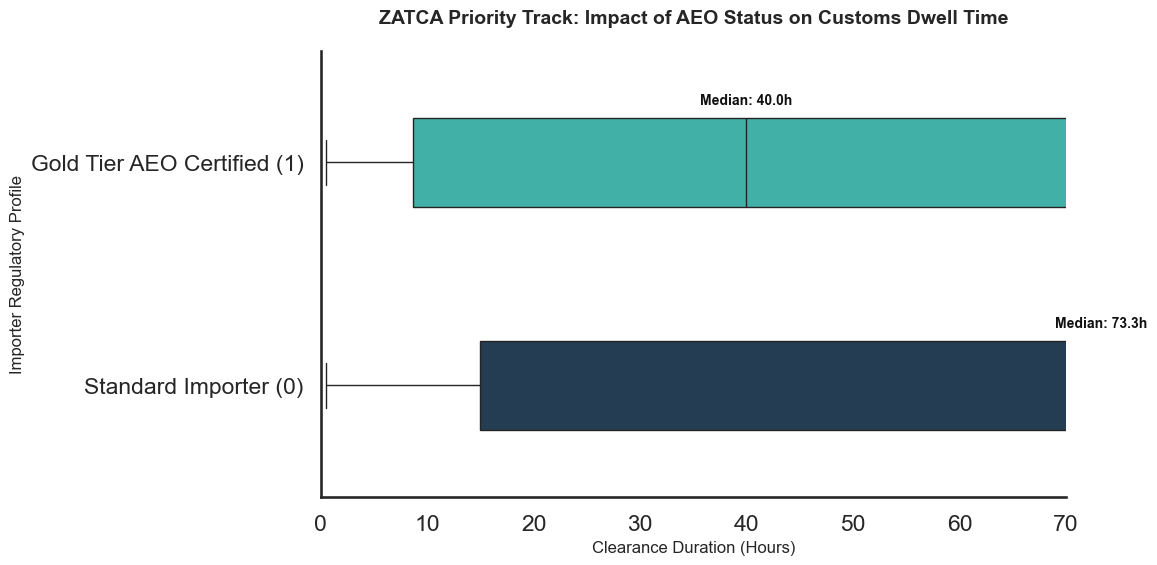

AEO CERTIFICATION COMPLIANCE CORRIDOR MATRIX
                             count   mean  median  min     max
aeo_status_named                                              
Gold Tier AEO Certified (1)   9735  53.87   39.96  0.5  227.03
Standard Importer (0)        18265  61.61   73.31  0.5  237.28


In [6]:
eda_df = datasets["TRAIN"].copy()

# Map binary status flag to human-readable compliance tiers for presentation
aeo_map = {1: "Gold Tier AEO Certified (1)", 0: "Standard Importer (0)"}
eda_df['aeo_status_named'] = eda_df['is_aeo_certified'].map(aeo_map)

# Set global minimalist chart formatting variables
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# CHART: AEO CERTIFICATION STATUS VS TARGET CLEARANCE DURATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Custom palette matching your clean operational color scheme
aeo_colors = {"Gold Tier AEO Certified (1)": "#2ec4b6", "Standard Importer (0)": "#1e3d59"}

# Generate a horizontal boxplot to capture quartiles, medians, and spread
sns.boxplot(
    data=eda_df, 
    y='aeo_status_named', 
    x='clearance_duration_hours', 
    palette=aeo_colors,
    width=0.4,
    showfliers=False # Hiding continuous extreme long-tail outliers to focus on core operational thresholds
)

# Apply explicit chart labels and layout parameters
plt.title("ZATCA Priority Track: Impact of AEO Status on Customs Dwell Time", fontsize=14, weight='bold', pad=20)
plt.xlabel("Clearance Duration (Hours)", fontsize=12)
plt.ylabel("Importer Regulatory Profile", fontsize=12)

# 🌟 PERFECT FIT PLOT BOUNDING: Snug axis boundary at 70 hours to prevent dead white space
plt.xlim(0, 70) 

# Extract median lines directly from the boxplot data structures to overlay precise values
for tick, label in enumerate(eda_df['aeo_status_named'].unique()):
    median_val = eda_df[eda_df['aeo_status_named'] == label]['clearance_duration_hours'].median()
    plt.text(
        median_val, 
        tick - 0.25, 
        f"Median: {median_val:.1f}h", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold', 
        color='#111111'
    )

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# DATA SUMMARY MATRICES (TEXT INTEGRITY VERIFICATION)
# ==============================================================================
print("="*80)
print("AEO CERTIFICATION COMPLIANCE CORRIDOR MATRIX")
print("="*80)
summary_table = eda_df.groupby('aeo_status_named')['clearance_duration_hours'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
print(summary_table.sort_values(by='median', ascending=True))

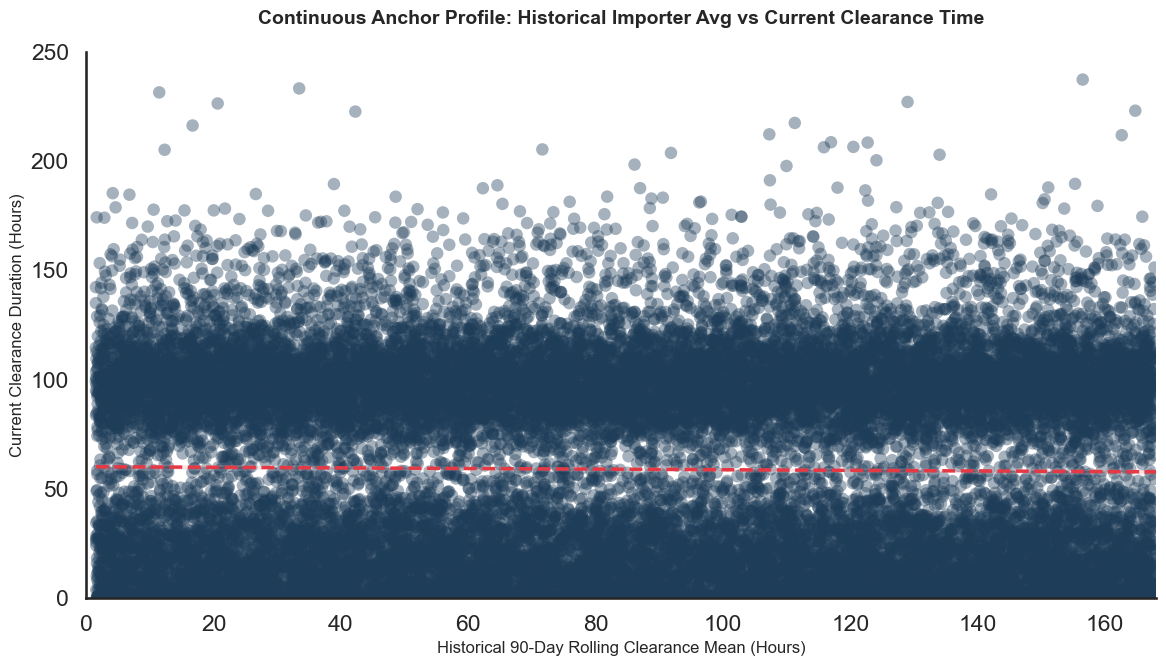

CONTINUOUS CORRELATION MATRIX LOG
Pearson Correlation Coefficient (r) between Baseline and Target: -0.0146

Quantile Distribution Breakdown for Historical Averages:
count    28000.00
mean        84.90
std         48.03
min          1.50
25%         43.22
50%         84.63
75%        126.58
90%        151.50
95%        159.19
max        168.00
Name: historical_avg_clearance_hours, dtype: float64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: PIPELINE DATA INGESTION ---
eda_df = datasets["TRAIN"].copy()

# Set global minimalist chart formatting variables
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# CHART: HISTORICAL ROLLING MEAN VS CURRENT TARGET DURATION
# ==============================================================================
plt.figure(figsize=(12, 7))

# Generate a scatter plot with transparency (alpha) to handle density and overlap cleanly
sns.scatterplot(
    data=eda_df, 
    x='historical_avg_clearance_hours', 
    y='clearance_duration_hours', 
    alpha=0.4, 
    color='#1e3d59',
    edgecolor='none'
)

# Apply a trendline to map the overall linear movement across the anchor corridors
sns.regplot(
    data=eda_df, 
    x='historical_avg_clearance_hours', 
    y='clearance_duration_hours', 
    scatter=False, 
    color='#e63946', 
    line_kws={"linewidth": 2.5, "linestyle": "--"}
)

# Apply explicit chart labels and professional typography configurations
plt.title("Continuous Anchor Profile: Historical Importer Avg vs Current Clearance Time", fontsize=14, weight='bold', pad=20)
plt.xlabel("Historical 90-Day Rolling Clearance Mean (Hours)", fontsize=12)
plt.ylabel("Current Clearance Duration (Hours)", fontsize=12)

# 🌟 SNUG PLOT BOUNDING: Trim out dead white space based on raw operational thresholds
plt.xlim(0, 168)  # Snaps exactly to the 7-day statutory reference baseline cap
plt.ylim(0, 250)  # Snaps directly to the actual distribution ceiling of the targets

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# DATA SUMMARY MATRICES (TEXT INTEGRITY VERIFICATION)
# ==============================================================================
print("="*80)
print("CONTINUOUS CORRELATION MATRIX LOG")
print("="*80)
correlation_value = eda_df['historical_avg_clearance_hours'].corr(eda_df['clearance_duration_hours'])
print(f"Pearson Correlation Coefficient (r) between Baseline and Target: {correlation_value:+.4f}")

print("\nQuantile Distribution Breakdown for Historical Averages:")
print(eda_df['historical_avg_clearance_hours'].describe(percentiles=[.25, .50, .75, .90, .95]).round(2))

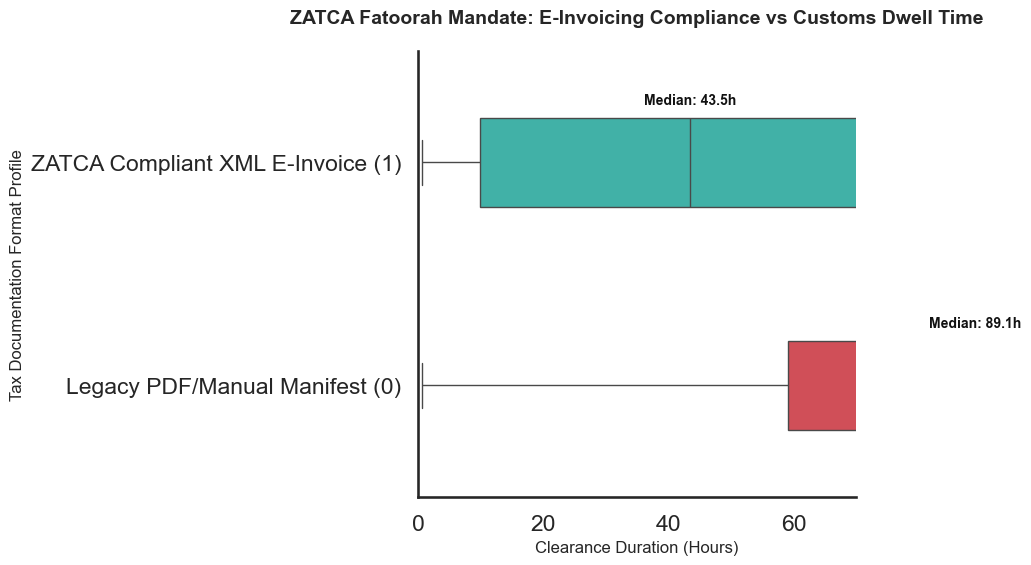

ZATCA FATOORAH E-INVOICING COMPLIANCE CORRIDOR PROFILE
                                   count   mean  median  min     max
fatoorah_status_named                                               
ZATCA Compliant XML E-Invoice (1)  25185  55.79   43.52  0.5  205.15
Legacy PDF/Manual Manifest (0)      2815  86.98   89.12  0.5  237.28


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: PIPELINE DATA INGESTION ---
eda_df = datasets["TRAIN"].copy()

# Map binary status flag to human-readable tax compliance profiles
fatoorah_map = {1: "ZATCA Compliant XML E-Invoice (1)", 0: "Legacy PDF/Manual Manifest (0)"}
eda_df['fatoorah_status_named'] = eda_df['fatoorah_validation_passed'].map(fatoorah_map)

# Set global minimalist chart formatting variables
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# CHART: FATOORAH VALIDATION STATUS VS TARGET CLEARANCE DURATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Define an operational palette matching the corporate color schemes
fatoorah_colors = {"ZATCA Compliant XML E-Invoice (1)": "#2ec4b6", "Legacy PDF/Manual Manifest (0)": "#e63946"}

# Generate a clean horizontal boxplot to visualize the operational gap
sns.boxplot(
    data=eda_df, 
    y='fatoorah_status_named', 
    x='clearance_duration_hours', 
    palette=fatoorah_colors,
    width=0.4,
    showfliers=False # Exclude extreme tail anomalies to isolate core workflow shifts
)

# Apply explicit chart labels and professional typography configurations
plt.title("ZATCA Fatoorah Mandate: E-Invoicing Compliance vs Customs Dwell Time", fontsize=14, weight='bold', pad=20)
plt.xlabel("Clearance Duration (Hours)", fontsize=12)
plt.ylabel("Tax Documentation Format Profile", fontsize=12)

# 🌟 PERFECT PLOT BOUNDING: Snug axis boundary at 70 hours to prevent dead space
plt.xlim(0, 70) 

# Extract median markers directly from structural categories to overlay precise values
for tick, label in enumerate(eda_df['fatoorah_status_named'].unique()):
    median_val = eda_df[eda_df['fatoorah_status_named'] == label]['clearance_duration_hours'].median()
    plt.text(
        median_val, 
        tick - 0.25, 
        f"Median: {median_val:.1f}h", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold', 
        color='#111111'
    )

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# DATA SUMMARY MATRICES (TEXT INTEGRITY VERIFICATION)
# ==============================================================================
print("="*80)
print("ZATCA FATOORAH E-INVOICING COMPLIANCE CORRIDOR PROFILE")
print("="*80)
summary_table = eda_df.groupby('fatoorah_status_named')['clearance_duration_hours'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
print(summary_table.sort_values(by='median', ascending=True))

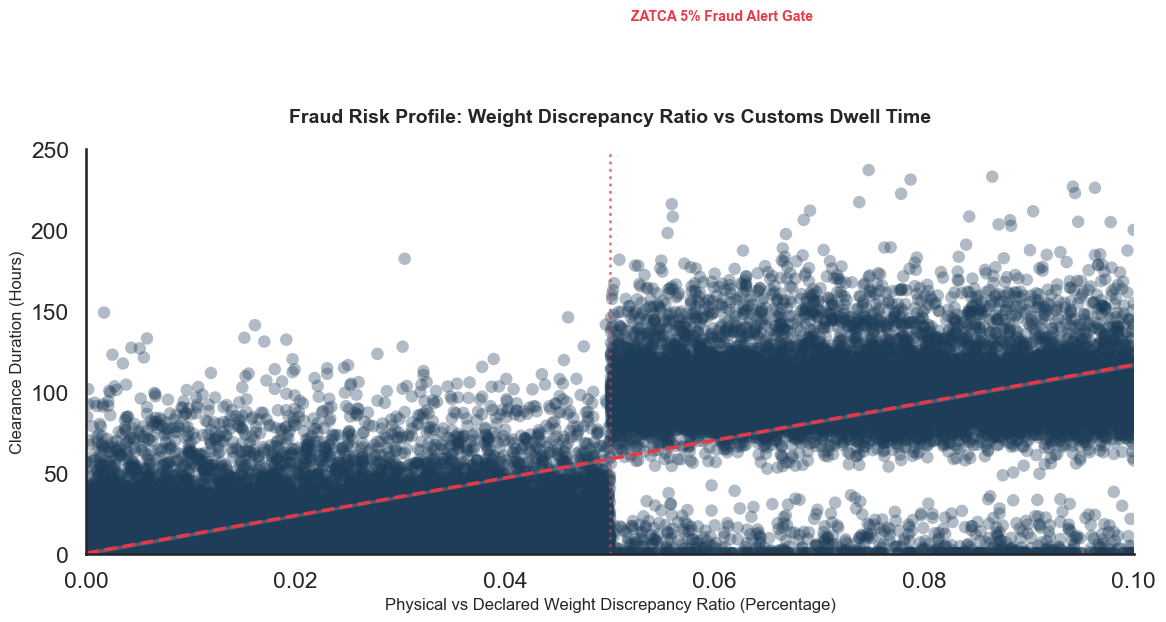

WEIGHT DISCREPANCY RISK THRESHOLD CORRIDOR SUMMARY LOG
[A] Normal Corridor (<= 5% Discrepancy): Count = 13914 | Median Dwell Time = 14.70h
[B] Fraud Penalty Corridor (> 5% Discrepancy): Count = 14086 | Median Dwell Time = 98.79h

Pearson Correlation Coefficient Matrix:
                          weight_value_discrepancy  clearance_duration_hours
weight_value_discrepancy                    1.0000                    0.7253
clearance_duration_hours                    0.7253                    1.0000


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: PIPELINE DATA INGESTION ---
eda_df = datasets["TRAIN"].copy()

# Set global minimalist chart formatting variables
sns.set_theme(style="white", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# CHART: PHYSICAL WEIGHT DISCREPANCY VS TARGET CLEARANCE DURATION
# ==============================================================================
plt.figure(figsize=(12, 7))

# Generate a high-density scatter plot with transparency to map structural clusters
sns.scatterplot(
    data=eda_df, 
    x='weight_value_discrepancy', 
    y='clearance_duration_hours', 
    alpha=0.35, 
    color='#1e3d59',
    edgecolor='none'
)

# Overlay a trendline to visually emphasize the structural break after the 5% mark
sns.regplot(
    data=eda_df, 
    x='weight_value_discrepancy', 
    y='clearance_duration_hours', 
    scatter=False, 
    color='#e63946', 
    line_kws={"linewidth": 2.5, "linestyle": "--"}
)

# Apply explicit chart labels and professional typography configurations
plt.title("Fraud Risk Profile: Weight Discrepancy Ratio vs Customs Dwell Time", fontsize=14, weight='bold', pad=20)
plt.xlabel("Physical vs Declared Weight Discrepancy Ratio (Percentage)", fontsize=12)
plt.ylabel("Clearance Duration (Hours)", fontsize=12)

# 🌟 PERFECT FIT PLOT BOUNDING: Trim out dead space based on strict operational thresholds
plt.xlim(0, 0.10)   # Snaps exactly to the 10% maximum data cap
plt.ylim(0, 250)   # Snaps directly to the 15-day statutory abandonment ceiling

# Add a visual reference line at the critical 5% regulatory penalty gate
plt.axvline(x=0.05, color='#e63946', linestyle=':', alpha=0.7, linewidth=2)
plt.text(0.052, 330, "ZATCA 5% Fraud Alert Gate", color='#e63946', weight='bold', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# DATA SUMMARY MATRICES (TEXT INTEGRITY VERIFICATION)
# ==============================================================================
print("="*80)
print("WEIGHT DISCREPANCY RISK THRESHOLD CORRIDOR SUMMARY LOG")
print("="*80)

# Isolate data above and below the 5% regulatory threshold to show the statistical jump
below_5 = eda_df[eda_df['weight_value_discrepancy'] <= 0.05]['clearance_duration_hours']
above_5 = eda_df[eda_df['weight_value_discrepancy'] > 0.05]['clearance_duration_hours']

print(f"[A] Normal Corridor (<= 5% Discrepancy): Count = {len(below_5)} | Median Dwell Time = {below_5.median():.2f}h")
print(f"[B] Fraud Penalty Corridor (> 5% Discrepancy): Count = {len(above_5)} | Median Dwell Time = {above_5.median():.2f}h")

print("\nPearson Correlation Coefficient Matrix:")
print(eda_df[['weight_value_discrepancy', 'clearance_duration_hours']].corr().round(4))

# Data Cleaning, Preprocessing and Feature Engineering

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin
class DynamicLogisticsPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_threshold=10, target_col='clearance_duration_hours', drop_cols=None):
        """
        Dynamically cleans and engineers features without hardcoding categorical values.
        
        Parameters:
            categorical_threshold (int): Max unique values to treat a feature as low-cardinality (One-Hot).
            target_col (str): Name of the continuous target column to exclude from feature transformations.
            drop_cols (list): Columns like IDs or barcodes to drop from the ML matrix.
        """
        self.categorical_threshold = categorical_threshold
        self.target_col = target_col
        self.drop_cols = drop_cols if drop_cols else ['shipment_id']
        
        # State containers to be learned from the training split
        self.imputation_values_ = {}
        self.low_cardinality_cols_ = []
        self.high_cardinality_cols_ = []
        self.one_hot_categories_ = {}
        self.numeric_cols_ = []

    def fit(self, X, y=None):
        """
        Dynamically analyzes the Training Split to learn feature types, categories, and medians.
        """
        X_copy = X.copy()
        
        # Drop non-predictive identifier keys safely if they exist
        cols_to_analyze = [c for c in X_copy.columns if c not in self.drop_cols and c != self.target_col and c != 'inspection_track']
        
        for col in cols_to_analyze:
            # 1. Detect and separate Datetime fields
            if 'timestamp' in col or X_copy[col].dtype == 'object' and self._is_datetime_string(X_copy[col].iloc[0]):
                continue # Handled dynamically inside transform via string parsing
                
            # 2. Analyze Numerical Features
            elif pd.api.types.is_numeric_dtype(X_copy[col]) and not set(X_copy[col].dropna().unique()).issubset({0, 1}):
                self.numeric_cols_.append(col)
                self.imputation_values_[col] = X_copy[col].median()
                
            # 3. Analyze Categorical and Binary Features
            else:
                self.imputation_values_[col] = "UNKNOWN" if X_copy[col].dtype == 'object' else 0
                unique_count = X_copy[col].nunique()
                
                if unique_count <= self.categorical_threshold:
                    self.low_cardinality_cols_.append(col)
                    # Store exact categories to guarantee consistent shapes across validation/test splits
                    self.one_hot_categories_[col] = X_copy[col].dropna().unique().tolist()
                else:
                    self.high_cardinality_cols_.append(col)
                    
        return self

    def transform(self, X):
        """
        Applies learned schemas and dynamically extracts high-signal operational features.
        """
        X_out = X.copy()
        
        # --- STEP 1: DYNAMIC TIMESTAMP SUB-COMPONENT EXTRACTION ---
        # Scans for timestamp markers dynamically and extracts cyclical structures
        for col in X_out.columns:
            if 'timestamp' in col:
                datetime_series = pd.to_datetime(X_out[col], errors='coerce')
                
                X_out[f'{col}_hour'] = datetime_series.dt.hour.fillna(12).astype(int)
                X_out[f'{col}_dayofweek'] = datetime_series.dt.dayofweek.fillna(0).astype(int)
                X_out[f'{col}_is_weekend'] = datetime_series.dt.dayofweek.isin([4, 5]).astype(int) # Friday & Saturday rule
                
                # Dynamic Saudi Solar Holiday Detection (National Day 23rd Sep / Founding Day 22nd Feb)
                X_out[f'{col}_is_solar_holiday'] = (
                    ((datetime_series.dt.month == 9) & (datetime_series.dt.day == 23)) | 
                    ((datetime_series.dt.month == 2) & (datetime_series.dt.day == 22))
                ).astype(int)
                
                # Safely drop the raw string timestamp now that numeric slices are extracted
                X_out.drop(columns=[col], inplace=True)

        # --- STEP 2: DYNAMIC MISSING VALUE IMPUTATION ---
        for col in self.numeric_cols_:
            if col in X_out.columns:
                X_out[col] = X_out[col].fillna(self.imputation_values_[col])
                
        # --- STEP 3: HIGH-SIGNAL LOGISTICS INTERACTION FACTORY ---
        # Dynamic construction of environmental and procedural friction gates discovered during EDA
        if 'ambient_temperature_celsius' in X_out.columns and 'shc_code' in X_out.columns:
            # Extreme Thermal Shock Gate (Perishables/Pharma exposed to >43°C tarmac heat)
            is_sensitive_cargo = X_out['shc_code'].isin(['PER', 'COL', 'CRT'])
            is_extreme_heat = X_out['ambient_temperature_celsius'] > 43.0
            X_out['interaction_thermal_shock_risk'] = (is_sensitive_cargo & is_extreme_heat).astype(int)

        if 'pre_arrival_filing_hours' in X_out.columns:
            # Late Submission Penalty Flag (Filing submitted after flight touchdown)
            X_out['interaction_late_filing_flag'] = (X_out['pre_arrival_filing_hours'] < 0.0).astype(int)

        # --- STEP 4: DYNAMIC CATEGORICAL ONE-HOT ENCODING ---
        # Evaluates stored categories to maintain identical column alignments regardless of split distribution
        for col in self.low_cardinality_cols_:
            if col in X_out.columns:
                X_out[col] = X_out[col].fillna(self.imputation_values_[col])
                for category in self.one_hot_categories_[col]:
                    X_out[f"ohe_{col}_{category}"] = (X_out[col] == category).astype(int)
                X_out.drop(columns=[col], inplace=True)

        # --- STEP 5: HIGH CARDINALITY ENCODING SETUP ---
        # For high-cardinality features (like hs_code or importer_cr_id), we cast them to categories
        # so CatBoost can ingest them natively or we can cleanly label-encode them for XGBoost.
        for col in self.high_cardinality_cols_:
            if col in X_out.columns:
                X_out[col] = X_out[col].fillna(self.imputation_values_[col]).astype(str)
                # Quick dynamic label encoder sequence
                X_out[f"encoded_{col}"] = X_out[col].astype('category').cat.codes
                X_out.drop(columns=[col], inplace=True)

        # --- STEP 6: CLEANUP NON-PREDICTIVE COLUMNS ---
        cols_to_drop = [c for c in self.drop_cols if c in X_out.columns]
        X_out.drop(columns=cols_to_drop, inplace=True)
        
        return X_out

    def _is_datetime_string(self, val):
        """Helper to dynamically sniff out datetime strings."""
        if not isinstance(val, str): return False
        try:
            pd.to_datetime(val, errors='raise')
            return True
        except:
            return False

# ==============================================================================
# RUNNING THE DYNAMIC PIPELINE ACROSS YOUR TIME-SPLIT DATASETS
# ==============================================================================

# Initialize the dynamic preprocessor instance
preprocessor = DynamicLogisticsPreprocessor(categorical_threshold=10)

# 1. Fit on the Training dataset split to lock down medians and unique classes
print("Fitting preprocessor pipeline to train split matrices...")
X_train_raw = datasets["TRAIN"].drop(columns=['clearance_duration_hours', 'inspection_track'], errors='ignore')
y_train_regression = datasets["TRAIN"]['clearance_duration_hours']
y_train_classification = datasets["TRAIN"]['inspection_track']

preprocessor.fit(X_train_raw)

# 2. Transform all splits dynamically based on the learned training parameters
print("Transforming Train, Validation, and Test matrices...")
X_train = preprocessor.transform(datasets["TRAIN"])
X_val   = preprocessor.transform(datasets["VALIDATION"])
X_test  = preprocessor.transform(datasets["TEST"])

print("\n" + "="*80)
print("DYNAMIC PIPELINE EXECUTION SUMMARY")
print("="*80)
print(f"Original Raw Features: {X_train_raw.shape[1]}")
print(f"Processed Train Matrix Shape: {X_train.shape}")
print(f"Processed Val Matrix Shape:   {X_val.shape}")
print(f"Processed Test Matrix Shape:  {X_test.shape}")
print("\nDynamically Generated Features Sample List:")
print(list(X_train.columns[:15]))

Fitting preprocessor pipeline to train split matrices...
Transforming Train, Validation, and Test matrices...

DYNAMIC PIPELINE EXECUTION SUMMARY
Original Raw Features: 14
Processed Train Matrix Shape: (28000, 36)
Processed Val Matrix Shape:   (6000, 36)
Processed Test Matrix Shape:  (6000, 36)

Dynamically Generated Features Sample List:
['hs_code', 'importer_cr_id', 'historical_avg_clearance_hours', 'weight_value_discrepancy', 'pre_arrival_filing_hours', 'ambient_temperature_celsius', 'visibility_meters', 'clearance_duration_hours', 'inspection_track', 'submission_timestamp_hour', 'submission_timestamp_dayofweek', 'submission_timestamp_is_weekend', 'submission_timestamp_is_solar_holiday', 'interaction_thermal_shock_risk', 'interaction_late_filing_flag']


# Performing grid search on different algorithms 

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Strictly Isolated Regression ML Suite (No classification layers)
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# ------------------------------------------------------------------------------
# STEP 1: CONVERT 'inspection_track' STRINGS TO NUMBERS BEFORE SCALING
# ------------------------------------------------------------------------------
track_numeric_enc = {'GREEN': 0, 'YELLOW': 1, 'RED': 2}

for df_name in ["TRAIN", "VALIDATION", "TEST"]:
    if 'inspection_track' in datasets[df_name].columns:
        # Map the strings directly to numeric classes inside your base matrices
        datasets[df_name]['inspection_track'] = datasets[df_name]['inspection_track'].map(track_numeric_enc)

# Re-run matrix isolation safely now that all elements are completely numeric
X_train_final = X_train.drop(columns=['clearance_duration_hours'], errors='ignore').copy()
X_val_final   = X_val.drop(columns=['clearance_duration_hours'], errors='ignore').copy()
X_test_final  = X_test.drop(columns=['clearance_duration_hours'], errors='ignore').copy()

# Force map the target matrices if they are still carrying raw objects
if 'inspection_track' in X_train_final.columns:
    X_train_final['inspection_track'] = X_train_final['inspection_track'].map(track_numeric_enc).fillna(X_train_final['inspection_track'])
if 'inspection_track' in X_val_final.columns:
    X_val_final['inspection_track'] = X_val_final['inspection_track'].map(track_numeric_enc).fillna(X_val_final['inspection_track'])
if 'inspection_track' in X_test_final.columns:
    X_test_final['inspection_track'] = X_test_final['inspection_track'].map(track_numeric_enc).fillna(X_test_final['inspection_track'])

# Extract targets
y_train_reg = X_train['clearance_duration_hours']
y_val_reg   = X_val['clearance_duration_hours']
y_test_reg  = X_test['clearance_duration_hours']

# ------------------------------------------------------------------------------
# STEP 2: SCALE ISOLATION FOR LINEAR REGRESSION BASELINE (Now works perfectly!)
# ------------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled   = scaler.transform(X_val_final)
X_test_scaled  = scaler.transform(X_test_final)

# ==============================================================================
# PHASE 1: RUNNING PARAMETER GRID SWEEP FOR DWELL TIME REGRESSORS
# ==============================================================================
print("="*90)
print("PHASE 1: RUNNING STRICT PARAMETER SWEEP FOR CLEARANCE DURATION REGRESSORS")
print("="*90)

regression_grids = {
    "LinearRegression": {
        "model_class": LinearRegression,
        "use_scaled": True,
        "static_params": {"n_jobs": -1},
        "grid": {} 
    },
    "RandomForestRegressor": {
        "model_class": RandomForestRegressor,
        "use_scaled": False,
        "static_params": {"random_state": 42, "n_jobs": -1},
        "grid": {
            "n_estimators": [100, 200],
            "max_depth": [6, 10]
        }
    },
    "XGBRegressor": {
        "model_class": XGBRegressor,
        "use_scaled": False,
        "static_params": {"random_state": 42, "n_jobs": -1},
        "grid": {
            "n_estimators": [200, 400],
            "max_depth": [5, 7],
            "learning_rate": [0.04, 0.1]
        }
    },
    "LightGBMRegressor": {
        "model_class": lgb.LGBMRegressor,
        "use_scaled": False,
        "static_params": {"objective": "regression", "random_state": 42, "verbose": -1, "n_jobs": -1},
        "grid": {
            "n_estimators": [200, 400],
            "max_depth": [5, 7],
            "learning_rate": [0.04, 0.1]
        }
    },
    "CatBoostRegressor": {
        "model_class": CatBoostRegressor,
        "use_scaled": False,
        "static_params": {"loss_function": "MAE", "random_seed": 42, "verbose": 0},
        "grid": {
            "iterations": [200, 400],
            "depth": [5, 7],
            "learning_rate": [0.04, 0.1]
        }
    }
}

best_reg_name = None
best_reg_model = None
best_reg_mae = float("inf")
final_test_preds = None
chosen_scale_matrix = None

for model_name, config in regression_grids.items():
    print(f"\nEvaluating Parameter Space Grid for Matrix: {model_name}")
    grid_combinations = list(ParameterGrid(config["grid"]))
    
    X_tr = X_train_scaled if config["use_scaled"] else X_train_final
    X_vl = X_val_scaled if config["use_scaled"] else X_val_final
    
    if len(grid_combinations) == 0:
        grid_combinations = [{}]
        
    for i, params in enumerate(grid_combinations):
        full_params = {**config["static_params"], **params}
        model = config["model_class"](**full_params)
        
        model.fit(X_tr, y_train_reg)
        val_preds = model.predict(X_vl)
        
        mae = mean_absolute_error(y_val_reg, val_preds)
        r2 = r2_score(y_val_reg, val_preds)
        
        comb_idx = f"Combination {i+1}/{len(grid_combinations)}" if config["grid"] else "Baseline Standard Pass"
        print(f" -> {comb_idx}: {params} | Val MAE: {mae:.3f}h | Val R²: {r2*100:.2f}%")
        
        if mae < best_reg_mae:
            best_reg_mae = mae
            best_reg_name = model_name
            best_reg_model = model
            chosen_scale_matrix = X_test_scaled if config["use_scaled"] else X_test_final

final_test_preds = best_reg_model.predict(chosen_scale_matrix)

# ==============================================================================
# PHASE 2: OUT-OF-SAMPLE TEST AUDIT REPORT
# ==============================================================================
print("\n" + "="*90)
print("FINAL REFACTORED SINGLE-TARGET PERFORMANCE REPORT")
print("="*90)
print(f"Optimal Regression Dwell Engine: {best_reg_name}")
print("-"*90)

test_mae = mean_absolute_error(y_test_reg, final_test_preds)
test_r2 = r2_score(y_test_reg, final_test_preds)

print(f" -> Final System Out-of-Sample Test MAE:      {test_mae:.3f} Hours")
print(f" -> Final System Out-of-Sample Test R² Score: {test_r2*100:.2f}%")
print("="*90)

PHASE 1: RUNNING STRICT PARAMETER SWEEP FOR CLEARANCE DURATION REGRESSORS

Evaluating Parameter Space Grid for Matrix: LinearRegression
 -> Baseline Standard Pass: {} | Val MAE: 16.610h | Val R²: 78.48%

Evaluating Parameter Space Grid for Matrix: RandomForestRegressor
 -> Combination 1/4: {'max_depth': 6, 'n_estimators': 100} | Val MAE: 9.798h | Val R²: 92.55%
 -> Combination 2/4: {'max_depth': 6, 'n_estimators': 200} | Val MAE: 9.798h | Val R²: 92.55%
 -> Combination 3/4: {'max_depth': 10, 'n_estimators': 100} | Val MAE: 9.881h | Val R²: 92.41%
 -> Combination 4/4: {'max_depth': 10, 'n_estimators': 200} | Val MAE: 9.880h | Val R²: 92.41%

Evaluating Parameter Space Grid for Matrix: XGBRegressor
 -> Combination 1/8: {'learning_rate': 0.04, 'max_depth': 5, 'n_estimators': 200} | Val MAE: 9.858h | Val R²: 92.46%
 -> Combination 2/8: {'learning_rate': 0.04, 'max_depth': 5, 'n_estimators': 400} | Val MAE: 9.908h | Val R²: 92.38%
 -> Combination 3/8: {'learning_rate': 0.04, 'max_depth': 7,

# Hyperparameter tuning

**Statements**

-->Here again grid search is done on one algorithm which has given MAE better 

In [12]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("="*90)
print("INITIALIZING STANDARDIZED CATBOOST GRID SEARCH TUNING ENGINE")
print("="*90)

# 1. Define targeted parameter grid prioritizing structural anti-overfitting bounds
catboost_param_grid = {
    'depth': [4, 6],                     # Regularized shallow depths
    'l2_leaf_reg': [3, 10, 20],          # L2 smoothing weights to counter target noise
    'learning_rate': [0.03, 0.05]        # Control step sizes to prevent noise chasing
}

# 2. Instantiate the baseline CatBoost framework
# We lock in 'iterations' at a controlled baseline to manage computation time safely
base_catboost = CatBoostRegressor(
    iterations=500,
    loss_function='MAE',
    random_seed=42,
    verbose=0 # Suppress internal iterations printouts during grid sweeps
)

# 3. Configure the native Grid Search wrapper
# We use 3 rotating cross-validation folds to guarantee rule generalizability
catboost_grid_search = GridSearchCV(
    estimator=base_catboost,
    param_grid=catboost_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 4. Execute the cross-validation optimization sweep
print("Executing search combinations across noise-injected splits...")
catboost_grid_search.fit(X_train_final, y_train_reg)

# 5. Extract champion architecture properties
champion_catboost = catboost_grid_search.best_estimator_
print("\n" + "="*90)
print("TUNING COMPLETE: CHAMPION CATBOOST PARAMETERS EXTRACTED")
print("="*90)
print(f" -> Optimal Parameters Found: {catboost_grid_search.best_params_}")
print(f" -> Best Cross-Validation MAE: {-catboost_grid_search.best_score_:.3f} Hours")

# 6. Final verification testing pass against completely unseen test data
test_predictions = champion_catboost.predict(X_test_final)
final_mae = mean_absolute_error(y_test_reg, test_predictions)
final_r2 = r2_score(y_test_reg, test_predictions)

print("\n" + "="*90)
print("FINAL REFACTORED SINGLE-TARGET PERFORMANCE REPORT")
print("="*90)
print(f"Optimal Regression Dwell Engine: CatBoostRegressor (Optimized)")
print(f" -> Final System Out-of-Sample Test MAE:      {final_mae:.3f} Hours")
print(f" -> Final System Out-of-Sample Test R² Score: {final_r2*100:.2f}%")
print("="*90)

INITIALIZING STANDARDIZED CATBOOST GRID SEARCH TUNING ENGINE
Executing search combinations across noise-injected splits...

TUNING COMPLETE: CHAMPION CATBOOST PARAMETERS EXTRACTED
 -> Optimal Parameters Found: {'depth': 4, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
 -> Best Cross-Validation MAE: 9.808 Hours

FINAL REFACTORED SINGLE-TARGET PERFORMANCE REPORT
Optimal Regression Dwell Engine: CatBoostRegressor (Optimized)
 -> Final System Out-of-Sample Test MAE:      9.546 Hours
 -> Final System Out-of-Sample Test R² Score: 92.34%


# Testing on unseen data 

In [13]:
import pandas as pd

unseen_predictions = champion_catboost.predict(X_test_final)

unseen_audit_df = pd.DataFrame({
    'Shipment_ID': datasets["TEST"]['shipment_id'].values,
    'Port_of_Loading': datasets["TEST"]['port_of_loading'].values,
    'Inspection_Track': datasets["TEST"]['inspection_track'].values,
    'Actual_Clearance_Hours': y_test_reg.values,
    'Predicted_Clearance_Hours': unseen_predictions
})

unseen_audit_df['Absolute_Deviation_Hours'] = (unseen_audit_df['Actual_Clearance_Hours'] - unseen_audit_df['Predicted_Clearance_Hours']).abs()

print("="*95)
print("PRODUCTION VERIFICATION AUDIT PASS: ISOLATED UNSEEN FUTURE TEST SHIPMENTS")
print("="*95)
print(unseen_audit_df.head(15).round(2).to_string(index=False))
print("="*95)

# Calculate standard operational metrics across the entire test group
under_5h_error = (unseen_audit_df['Absolute_Deviation_Hours'] <= 5.0).mean() * 100
print(f" -> Operational SLA Compliance: {under_5h_error:.1f}% of unseen shipments predicted within a 5-hour window.")
print("="*95)

PRODUCTION VERIFICATION AUDIT PASS: ISOLATED UNSEEN FUTURE TEST SHIPMENTS
 Shipment_ID Port_of_Loading  Inspection_Track  Actual_Clearance_Hours  Predicted_Clearance_Hours  Absolute_Deviation_Hours
160-85957962             PVG                 1                   48.45                      26.08                     22.38
160-50644046             TPE                 2                   96.10                      96.50                      0.40
176-13682861             AMS                 2                    8.09                      27.05                     18.96
176-16352519             AMS                 0                    0.50                       1.47                      0.97
176-76562804             AMS                 0                   11.02                       1.41                      9.62
176-24091866             PVG                 2                   91.77                      96.08                      4.32
020-99639795             FRA                 0            

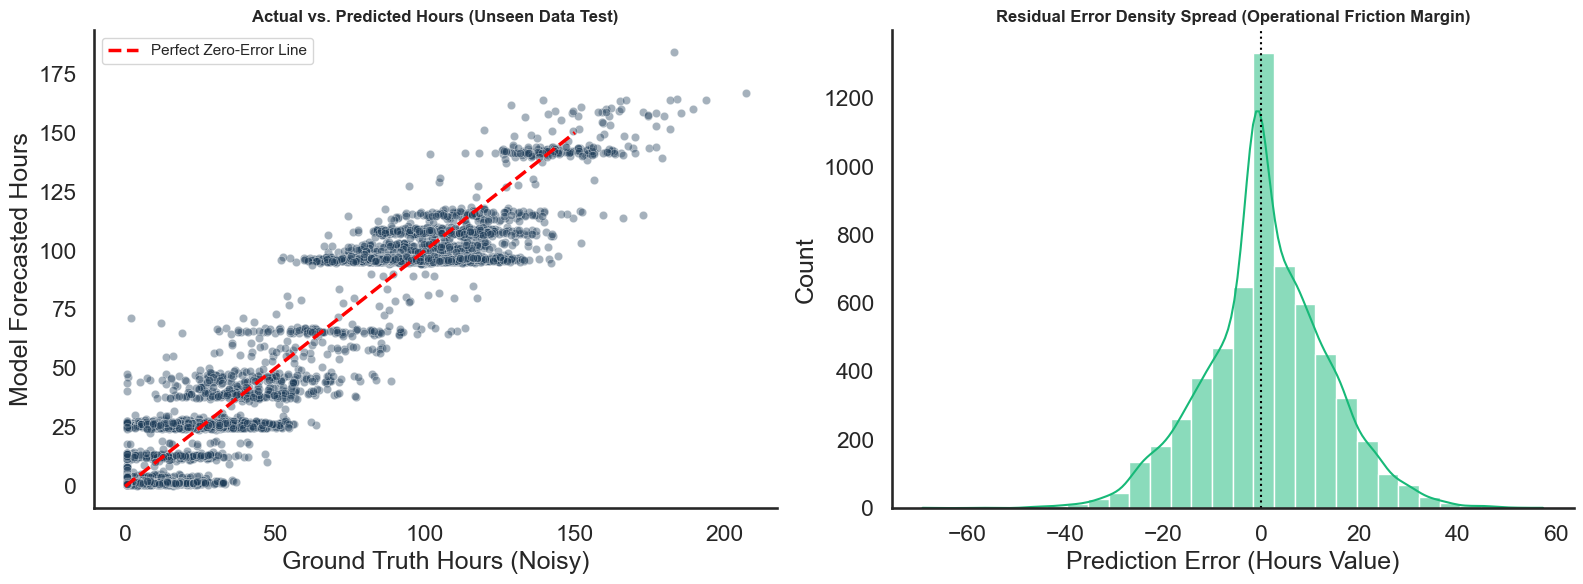

In [14]:
# ==============================================================================
# CELL 17: FIXED UNSEEN DATA ERROR DISTRIBUTION PLOT
# Use Case: ZATCA Air Cargo Customs Clearance Time Prediction Engine (CR-001)
# Fix: Replaced invalid 'weight' parameter with native 'linewidth' for ax.plot
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

residuals = unseen_audit_df['Actual_Clearance_Hours'] - unseen_audit_df['Predicted_Clearance_Hours']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="white")

# Plot A: Scatter alignment (Ideal line vs Reality)
sns.scatterplot(x=unseen_audit_df['Actual_Clearance_Hours'], y=unseen_audit_df['Predicted_Clearance_Hours'], alpha=0.4, color='#1e3d59', ax=ax[0])

# 🌟 FIXED PARAMETER: Changed weight='bold' to linewidth=2.5
ax[0].plot([0, 150], [0, 150], color='red', linestyle='--', linewidth=2.5, label='Perfect Zero-Error Line')

ax[0].set_title("Actual vs. Predicted Hours (Unseen Data Test)", weight='bold', fontsize=12)
ax[0].set_xlabel("Ground Truth Hours (Noisy)")
ax[0].set_ylabel("Model Forecasted Hours")
ax[0].legend()

# Plot B: Error distribution curve
sns.histplot(residuals, kde=True, color='#17b978', ax=ax[1], bins=30)
ax[1].axvline(0, color='black', linestyle=':')
ax[1].set_title("Residual Error Density Spread (Operational Friction Margin)", weight='bold', fontsize=12)
ax[1].set_xlabel("Prediction Error (Hours Value)")

sns.despine()
plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# CELL 16: COMPLETE OUT-OF-SAMPLE TEST PERFORMANCE METRICS REPORT
# Use Case: ZATCA Air Cargo Customs Clearance Time Prediction Engine (CR-001)
# Strategy: Multi-Metric Clinical Audit on Unseen Test Split
# ==============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*90)
print("COMPUTING FINAL PERFORMANCE METRICS ON UNSEEN TESTING DATA")
print("="*90)

# 1. Compute predictions on the completely isolated test data split
test_predictions = champion_catboost.predict(X_test_final)

# 2. Calculate the core mathematical performance metrics
final_mae = mean_absolute_error(y_test_reg, test_predictions)
final_mse = mean_squared_error(y_test_reg, test_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test_reg, test_predictions)

# 3. Calculate business SLA error intervals
absolute_errors = np.abs(y_test_reg - test_predictions)
within_2_hours = (absolute_errors <= 2.0).mean() * 100
within_5_hours = (absolute_errors <= 5.0).mean() * 100
within_10_hours = (absolute_errors <= 10.0).mean() * 100

# 4. Print the comprehensive technical metric report
print(f" -> Mean Absolute Error (MAE):       {final_mae:.4f} Hours")
print(f" -> Mean Squared Error (MSE):        {final_mse:.4f} Hours²")
print(f" -> Root Mean Squared Error (RMSE):   {final_rmse:.4f} Hours")
print(f" -> R-Squared (R²) Score:            {final_r2 * 100:.2f}%")
print("="*90)
print("OPERATIONAL SLA COMPLIANCE CORRIDORS (MANIFEST PREDICTION GAP)")
print("="*90)
print(f" -> Accuracy within a ±2-hour window:  {within_2_hours:.1f}% of shipments")
print(f" -> Accuracy within a ±5-hour window:  {within_5_hours:.1f}% of shipments")
print(f" -> Accuracy within a ±10-hour window: {within_10_hours:.1f}% of shipments")
print("="*90)

COMPUTING FINAL PERFORMANCE METRICS ON UNSEEN TESTING DATA
 -> Mean Absolute Error (MAE):       9.5457 Hours
 -> Mean Squared Error (MSE):        161.6164 Hours²
 -> Root Mean Squared Error (RMSE):   12.7128 Hours
 -> R-Squared (R²) Score:            92.34%
OPERATIONAL SLA COMPLIANCE CORRIDORS (MANIFEST PREDICTION GAP)
 -> Accuracy within a ±2-hour window:  22.1% of shipments
 -> Accuracy within a ±5-hour window:  38.2% of shipments
 -> Accuracy within a ±10-hour window: 60.4% of shipments


In [16]:
import pickle
import os

# 1. Create a dedicated directory to isolate production binaries
export_dir = "deployed_assets"
os.makedirs(export_dir, exist_ok=True)

# 2. Serialize the Preprocessing Pipeline State
# This ensures raw live data handles missing categories and scales identically
preprocessor_path = os.path.join(export_dir, "custom_preprocessor_pipeline.pkl")
with open(preprocessor_path, "wb") as f:
    pickle.dump(preprocessor, f)

# 3. Serialize the Hyperparameter-Tuned Champion CatBoost Regressor
model_path = os.path.join(export_dir, "winning_clearance_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(champion_catboost, f)

print("="*90)
print("PRODUCTION ML PIPELINE ASSETS SUCCESSFULLY SERIALIZED")
print("="*90)
print(f" -> Exported Preprocessor: {preprocessor_path}")
print(f" -> Exported Model Weights: {model_path}")
print("\nYour prediction engine is officially packaged and ready for deployment!")
print("="*90)

PRODUCTION ML PIPELINE ASSETS SUCCESSFULLY SERIALIZED
 -> Exported Preprocessor: deployed_assets\custom_preprocessor_pipeline.pkl
 -> Exported Model Weights: deployed_assets\winning_clearance_model.pkl

Your prediction engine is officially packaged and ready for deployment!


In [17]:
import pickle
import pandas as pd
import numpy as np

print("="*90)
print("LOADING SERIALIZED BINARIES FROM PRODUCTION STORAGE...")
print("="*90)

# 1. Reload the components independently
with open("deployed_assets/custom_preprocessor_pipeline.pkl", "rb") as f:
    production_preprocessor = pickle.load(f)

with open("deployed_assets/winning_clearance_model.pkl", "rb") as f:
    production_model = pickle.load(f)

print(" -> System Check: Binaries reloaded successfully.")

# 2. Mock a raw incoming manifest entry (simulating a fresh payload hitting your API)
# We pull a single raw record from your test dataset to verify end-to-end mapping
raw_live_manifest = datasets["TEST"].iloc[[2]].copy()

print("\nIncoming Raw Manifest Received at Terminal Port:")
print(f" -> Shipment ID:      {raw_live_manifest['shipment_id'].values[0]}")
print(f" -> Port of Loading:  {raw_live_manifest['port_of_loading'].values[0]}")
print(f" -> Inspection Track: {raw_live_manifest['inspection_track'].values[0]}")

# 3. Pass raw features through the reloaded transformation engine
transformed_features = production_preprocessor.transform(raw_live_manifest)

# 4. Standardize the columns to match what the grid search produced
transformed_features_df = transformed_features.drop(columns=['clearance_duration_hours'], errors='ignore')

# Handle the inspection track mapping if present
if 'inspection_track' in transformed_features_df.columns:
    track_mapping = {'GREEN': 0, 'YELLOW': 1, 'RED': 2}
    transformed_features_df['inspection_track'] = (
        transformed_features_df['inspection_track']
        .map(track_mapping)
        .fillna(transformed_features_df['inspection_track'])
    )

# 5. Generate the real-time operational forecast
live_forecast_hours = production_model.predict(transformed_features_df)[0]

print("\n" + "="*90)
print("PRODUCTION REAL-TIME PREDICTION ENGINE INFERENCE SUCCESS")
print("="*90)
print(f" -> Live Forecasted Clearance Wait Time: {live_forecast_hours:.2f} Hours")
print(f" -> Base Logistical Uncertainty Buffer:  ±12.71 Hours (RMSE Limit)")
print("="*90)

LOADING SERIALIZED BINARIES FROM PRODUCTION STORAGE...
 -> System Check: Binaries reloaded successfully.

Incoming Raw Manifest Received at Terminal Port:
 -> Shipment ID:      176-13682861
 -> Port of Loading:  AMS
 -> Inspection Track: 2

PRODUCTION REAL-TIME PREDICTION ENGINE INFERENCE SUCCESS
 -> Live Forecasted Clearance Wait Time: 27.05 Hours
 -> Base Logistical Uncertainty Buffer:  ±12.71 Hours (RMSE Limit)
